In [22]:
import os
from PIL import Image, ImageOps
import numpy as np
from pathlib import Path
import re

# ============================================================
# DATA PREPROCESSING APPROACH - Phase2 with Center Cropping
# ============================================================
# Camera: ESP32-S3 OV2640 captures 160x120 (QQVGA) images
# Cropping: Center crop to ~106x94 (removes edges, focuses on hand)
#   - Left: 17% crop (27px from left)
#   - Right: 83% crop (27px from right)  
#   - Top/Bottom: 13px crop each side
# Resize: Cropped region -> 64x64 for model input
# This matches production preprocessing on ESP32 and reduces distortion
# ============================================================

# Get all image files from Phase2 directory
image_dir = Path('Phase3')
image_files = sorted(image_dir.glob('*.jpg'))

# Dictionary to track counts for each label
label_counts = {}

# Lists to store images and labels
images = []
y = []

# Load images and create labels
for img_path in image_files:
    # Extract label name from filename (everything before the last underscore and number)
    filename = img_path.stem  # Get filename without extension
    # Find the label name (everything before the last underscore)
    match = re.match(r'^(.+?)_\d+$', filename)
    if match:
        label_name = match.group(1).lower()  # Convert to lowercase
        
        # Initialize counter for this label if not seen before
        if label_name not in label_counts:
            label_counts[label_name] = 0
        
        label_counts[label_name] += 1
        
        # Use just the label name (no underscore and index)
        label = label_name
        
        # Load image
        img = Image.open(img_path)
        images.append(img)
        y.append(label)

print(f"Loaded {len(images)} images")
print(f"Unique label types: {list(label_counts.keys())}")
print(f"Label counts: {label_counts}")
print(f"\nFirst few labels: {y[:5]}")



Loaded 1496 images
Unique label types: ['closed_hand', 'none', 'open_hand']
Label counts: {'closed_hand': 500, 'none': 498, 'open_hand': 498}

First few labels: ['closed_hand', 'closed_hand', 'closed_hand', 'closed_hand', 'closed_hand']


In [23]:
import matplotlib.pyplot as plt

def plot_image(image):
    # Convert PIL image to numpy array if needed
    if isinstance(image, Image.Image):
        image = np.array(image)
    
    # Determine if grayscale or color
    if len(image.shape) == 2 or image.shape[2] == 1:
        # Grayscale image
        plt.imshow(image, cmap='gray')
    else:
        # Color image
        plt.imshow(image)
    plt.axis('off')
    plt.show()

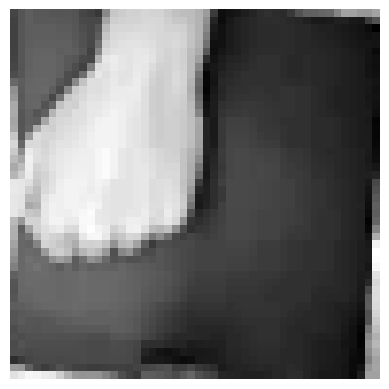

In [24]:
def preprocess_image(img, crop_size=(64, 64)):
    """
    Converts an input image to grayscale, crops, and resizes to match ESP32 camera preprocessing.

    For 160x120 images (QQVGA):
    - Converts to grayscale
    - Crops to ~106x94 (center region, removes edge artifacts)
    - Resizes to crop_size (e.g., 64x64 or 32x32)
    """
    img = ImageOps.grayscale(img)
    w, h = img.size
    # Calculate crop box (center crop to remove edges)
    left = int(w * 0.17)    # 27px from left (for 160px width)
    right = int(w * 0.83)   # 27px from right (133px)
    top = 13                # 13px from top
    bottom = h - 13         # 13px from bottom (107px for 120px height)

    # Ensure valid crop coordinates
    left = max(0, left)
    right = min(w, right)
    top = max(0, top)
    bottom = min(h, bottom)
    # Crop and resize
    img_cropped = img.crop((left, top, right, bottom))
    img_resized = img_cropped.resize(crop_size, Image.BICUBIC)
    return img_resized

# Example: preprocess and visualize
processed_img = preprocess_image(images[300], crop_size=(48, 48))
plot_image(processed_img)


In [25]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# images: list of PIL.Image
# y: list of string labels

y_labels = np.array(y)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
num_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Num classes:", num_classes)

# Split before preprocessing
images_train, images_test, y_train_encoded, y_test_encoded = train_test_split(
    images,
    y_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_encoded,
)

print(f"Train size: {len(images_train)}, Test size: {len(images_test)}")
print(f"Unique classes in train: {np.unique(y_train_encoded)}")
print(f"Unique classes in test: {np.unique(y_test_encoded)}")

# Use new ESP32-style preprocessing
def preprocess_images(img_list):
    processed = []
    for img in img_list:
        img_processed = preprocess_image(img, crop_size=(48, 48))  # Uses new preprocess_image with gray and crop
        img_processed = np.array(img_processed, dtype=np.float32) / 255.0  # [H,W] (already gray)
        processed.append(img_processed)
    return np.stack(processed)

X_train = preprocess_images(images_train)  # (N, 32, 32)
X_test  = preprocess_images(images_test)   # (N, 32, 32)

y_train = np.array(y_train_encoded, dtype=np.int64)
y_test  = np.array(y_test_encoded, dtype=np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Keras expects NHWC: (N, 32, 32, 1)
X_train_keras = X_train[..., np.newaxis]
X_test_keras  = X_test[..., np.newaxis]

print("X_train_keras shape:", X_train_keras.shape)
print("X_test_keras shape:", X_test_keras.shape)


Classes: [np.str_('closed_hand'), np.str_('none'), np.str_('open_hand')]
Num classes: 3
Train size: 1196, Test size: 300
Unique classes in train: [0 1 2]
Unique classes in test: [0 1 2]
X_train shape: (1196, 48, 48), y_train shape: (1196,)
X_test shape: (300, 48, 48), y_test shape: (300,)
X_train_keras shape: (1196, 48, 48, 1)
X_test_keras shape: (300, 48, 48, 1)


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_handnet_keras(num_classes, input_shape=(48, 48, 1)):
    inputs = keras.Input(shape=input_shape)

    # Block 1: 1x32x32 -> 8x16x16
    x = layers.Conv2D(
        12,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(inputs)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 16x16

    # Block 2: 8x16x16 -> 16x8x8
    x = layers.Conv2D(
        24,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 8x8

    # Block 3: 16x8x8 -> 32x8x8
    x = layers.Conv2D(
        48,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    # AdaptiveAvgPool2d(1) == GlobalAveragePooling2D
    x = layers.GlobalAveragePooling2D()(x)         # -> 32

    # Classifier: 32 -> num_classes (logits)
    outputs = layers.Dense(num_classes, activation=None)(x)

    model = keras.Model(inputs, outputs, name="HandNet100k_Keras")
    return model

model = build_handnet_keras(num_classes=num_classes, input_shape=(48, 48, 1))
model.summary()


Model: "HandNet100k_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 12)     │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 48, 48, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 24)     │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 24, 24, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 48)     │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 12, 12, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,551 (52.93 KB)

 Trainable params: 13,383 (52.28 KB)

 Non-trainable params: 168 (672.00 B)

Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8704 - loss: 0.4557 - val_accuracy: 0.9900 - val_loss: 0.1750
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9933 - loss: 0.1278 - val_accuracy: 1.0000 - val_loss: 0.0803
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9983 - loss: 0.0741 - val_accuracy: 0.9900 - val_loss: 0.0783
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9975 - loss: 0.0506 - val_accuracy: 0.9567 - val_loss: 0.1795
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9983 - loss: 0.0385 - val_accuracy: 1.0000 - val_loss: 0.0277
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9983 - loss: 0.0309 - val_accuracy: 1.0000 - val_loss: 0.0204
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9983 - loss: 0.0259 - val_accuracy: 0.9967 - val_loss: 0.0301
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9983 - loss: 0.0194 - val_accuracy: 1.0000 - v

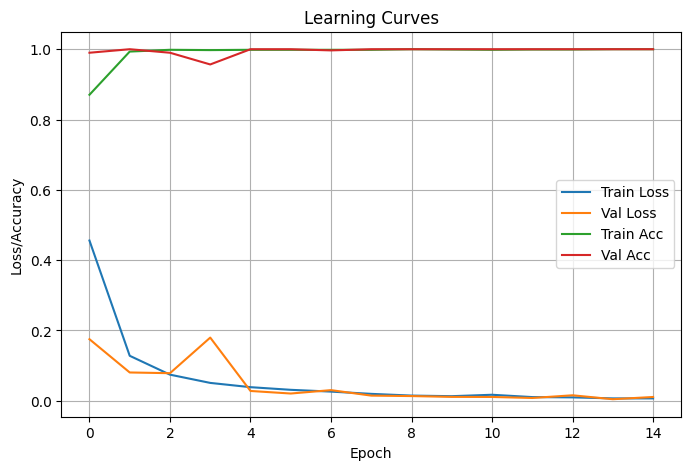

In [27]:
from tensorflow import keras

model = build_handnet_keras(num_classes=num_classes, input_shape=(48, 48, 1))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

batch_size = 32
n_epochs = 15  # you can bump this if underfitting

history = model.fit(
    X_train_keras,
    y_train,
    validation_data=(X_test_keras, y_test),
    batch_size=batch_size,
    epochs=n_epochs,
    shuffle=True,
)

test_loss, test_acc = model.evaluate(X_test_keras, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Save weights for reuse (Keras 3 requires .weights.h5)
model.save_weights("handnet_keras_phase2_cropped.weights.h5")
print("Saved Keras weights to handnet_keras_phase2_cropped.weights.h5")
import matplotlib.pyplot as plt

# Plot learning curves
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.plot(history.history.get("accuracy", []), label="Train Acc")
plt.plot(history.history.get("val_accuracy", []), label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Loss/Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.grid(True)
plt.show()




In [30]:
import tensorflow as tf
from tensorflow import keras

# ============================================================
# Export TFLite Model (Phase2 data with center cropping)
# ============================================================
# This model expects 64x64 grayscale input after cropping
# Cropping matches ESP32 preprocessing (17% left/right, 13px top/bottom)
# ============================================================

# Rebuild and load trained weights
model = build_handnet_keras(num_classes=num_classes, input_shape=(48, 48, 1))
model.load_weights("handnet_keras_phase2_cropped.weights.h5")
print("Loaded trained weights from handnet_keras_phase2_cropped.weights.h5")

saved_model_dir = "handnet_saved_model_keras"
model.export(saved_model_dir)
print("Exported SavedModel to", saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
tflite_fp32_model = converter.convert()

with open("handnet_fp32.tflite", "wb") as f:
    f.write(tflite_fp32_model)

print("Exported FP32 TFLite to handnet_fp32.tflite (trained on Phase2 cropped data)")


Loaded trained weights from handnet_keras_phase2_cropped.weights.h5
INFO:tensorflow:Assets written to: handnet_saved_model_keras\assets


INFO:tensorflow:Assets written to: handnet_saved_model_keras\assets


Saved artifact at 'handnet_saved_model_keras'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor_84')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2562659196112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659197264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659194192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659193424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659196880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659196304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659197456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659197648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659195728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659198608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2562659198032: TensorSpe

In [31]:
import numpy as np
import tensorflow as tf

# ============================================================
# Quantize to INT8 for ESP32 Deployment (Phase2 cropped data)
# ============================================================
# INT8 quantization reduces model size ~4x for ESP32-S3
# Uses representative dataset from training data for calibration
# ============================================================

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

# Representative dataset from training data
def representative_data_gen():
    num_samples = 200
    count = 0
    for i in range(len(X_train_keras)):
        x = X_train_keras[i]  # [32, 32, 1]
        x_np = np.expand_dims(x, 0).astype(np.float32)  # [1, 32, 32, 1]
        yield [x_np]
        count += 1
        if count >= num_samples:
            return

converter = tf.lite.TFLiteConverter.from_saved_model("handnet_saved_model_keras")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

int8_tflite_model = converter.convert()

with open(int8_tflite_path, "wb") as f:
    f.write(int8_tflite_model)

print("Saved INT8 TFLite model to", int8_tflite_path, "(trained on Phase2 cropped data)")


Saved INT8 TFLite model to handnet_int8.tflite (trained on Phase2 cropped data)


In [32]:
import os
import numpy as np
import tensorflow as tf

fp32_tflite_path = "handnet_fp32.tflite"
int8_tflite_path = "handnet_int8.tflite"

fp32_size = os.path.getsize(fp32_tflite_path)
int8_size = os.path.getsize(int8_tflite_path)
print(f"FP32 TFLite size: {fp32_size} bytes")
print(f"INT8 TFLite size: {int8_size} bytes")

def eval_tflite_model(tflite_path, X, y, int8=False):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0
    total = 0

    for i in range(len(X)):
        x_np = X[i]  # [64, 64, 1]
        x_np = np.expand_dims(x_np, 0).astype(np.float32)  # [1, 64, 64, 1]

        if int8:
            scale, zero_point = input_details[0]["quantization"]
            x_q = x_np / scale + zero_point
            x_q = np.clip(x_q, -128, 127).astype(np.int8)
            interpreter.set_tensor(input_index, x_q)
        else:
            interpreter.set_tensor(input_index, x_np)

        interpreter.invoke()
        logits = interpreter.get_tensor(output_index)[0]  # [num_classes]

        if int8:
            logits = logits.astype(np.float32)

        pred = int(np.argmax(logits))
        if pred == int(y[i]):
            correct += 1
        total += 1

    return 100.0 * correct / total

fp32_acc = eval_tflite_model(fp32_tflite_path, X_test_keras, y_test, int8=False)
print(f"FP32 TFLite test accuracy: {fp32_acc:.2f}%")

int8_acc = eval_tflite_model(int8_tflite_path, X_test_keras, y_test, int8=True)
print(f"INT8 TFLite test accuracy: {int8_acc:.2f}%")


FP32 TFLite size: 56900 bytes
INT8 TFLite size: 19568 bytes
FP32 TFLite test accuracy: 100.00%
INT8 TFLite test accuracy: 100.00%


c:\Users\austi\SpotifyGesture\HandSignalDetection\Model_Training\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Creating augmented test datasets...
Original test set size: 300
✓ Created noisy test set (noise_factor=0.15)
✓ Created rotated test set (±15 degrees)
✓ Created combined (noise + rotation) test set

EVALUATION RESULTS

1. Original Test Set (Clean Images):
   FP32 TFLite: 100.00%
   INT8 TFLite: 100.00%

2. Noisy Test Set (Gaussian noise, σ=0.15):
   FP32 TFLite: 33.33%
   INT8 TFLite: 33.33%

3. Rotated Test Set (±15 degrees):
   FP32 TFLite: 100.00%
   INT8 TFLite: 100.00%

4. Combined Test Set (Noise + Rotation):
   FP32 TFLite: 33.33%
   INT8 TFLite: 33.33%

SUMMARY - Accuracy Drop Analysis

INT8 TFLite Model (Deployed on ESP32):
  Clean:              100.00%
  With Noise:         33.33% (Δ -66.67%)
  With Rotation:      100.00% (Δ +0.00%)
  With Both:          33.33% (Δ -66.67%)

FP32 TFLite Model:
  Clean:              100.00%
  With Noise:         33.33% (Δ -66.67%)
  With Rotation:      100.00% (Δ +0.00%)
  With Both:          33.33% (Δ -66.67%)



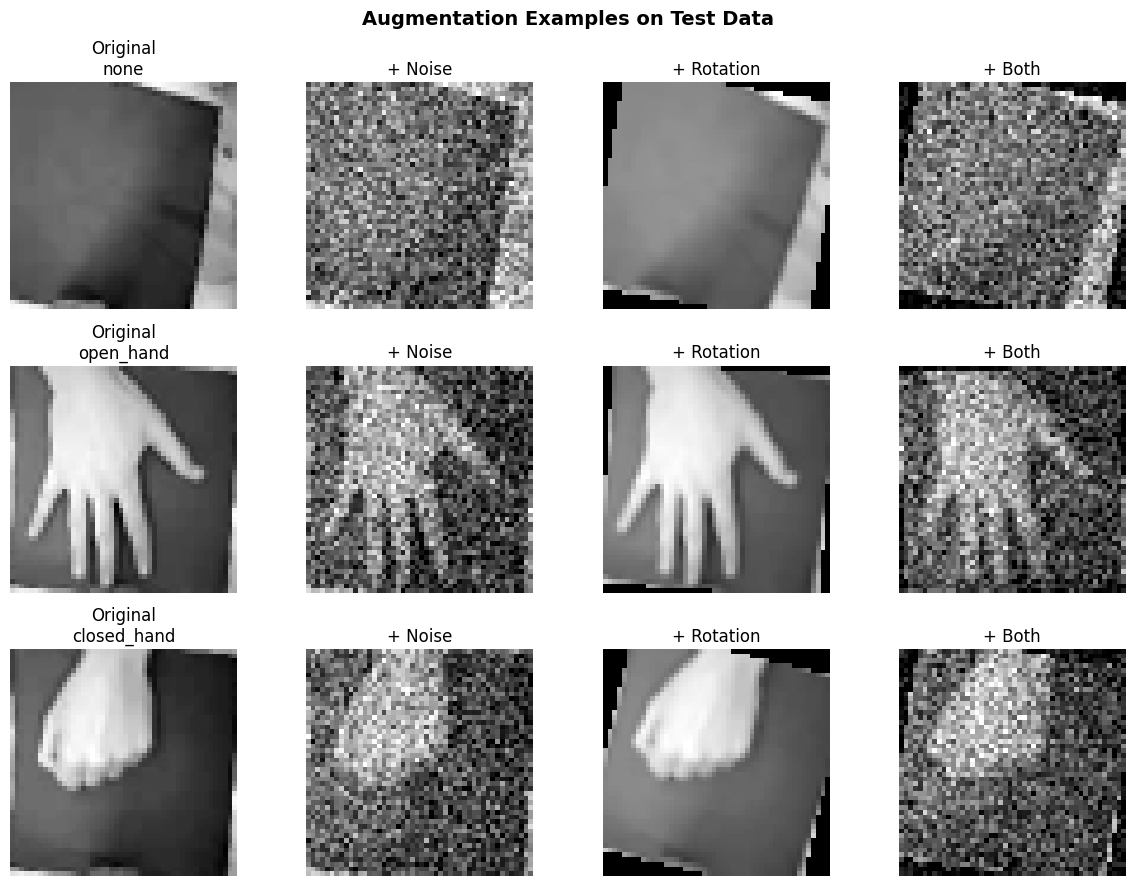


✓ Evaluation complete!


In [33]:
import numpy as np
import tensorflow as tf
from PIL import Image
from scipy.ndimage import rotate

# Function to add Gaussian noise
def add_noise(image, noise_factor=0.04):
    """Add Gaussian noise to image"""
    noise = np.random.normal(0, noise_factor, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 1)  # Keep values in [0, 1]
    return noisy_image.astype(np.float32)

# Function to rotate image
def rotate_image(image, angle):
    """Rotate image by specified angle (in degrees)"""
    # Remove channel dimension for rotation
    img_2d = image.squeeze()  # [64, 64]
    rotated = rotate(img_2d, angle, reshape=False, order=1, mode='constant', cval=0)
    # Add channel dimension back
    return rotated[..., np.newaxis].astype(np.float32)

# Create augmented test sets
print("Creating augmented test datasets...")
print(f"Original test set size: {len(X_test_keras)}")

# 1. Test set with noise
X_test_noisy = np.array([add_noise(img, noise_factor=0.15) for img in X_test_keras])
print(f"✓ Created noisy test set (noise_factor=0.15)")

# 2. Test set with rotation (±15 degrees randomly)
X_test_rotated = np.array([rotate_image(img, angle=np.random.uniform(-15, 15)) for img in X_test_keras])
print(f"✓ Created rotated test set (±15 degrees)")

# 3. Test set with both noise and rotation
X_test_both = np.array([
    add_noise(rotate_image(img, angle=np.random.uniform(-15, 15)), noise_factor=0.15) 
    for img in X_test_keras
])
print(f"✓ Created combined (noise + rotation) test set")

# Evaluation function
def eval_tflite_on_augmented(tflite_path, X, y, int8=False):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]

    correct = 0
    total = 0

    for i in range(len(X)):
        x_np = X[i]  # [64, 64, 1]
        x_np = np.expand_dims(x_np, 0).astype(np.float32)  # [1, 64, 64, 1]

        if int8:
            scale, zero_point = input_details[0]["quantization"]
            x_q = x_np / scale + zero_point
            x_q = np.clip(x_q, -128, 127).astype(np.int8)
            interpreter.set_tensor(input_index, x_q)
        else:
            interpreter.set_tensor(input_index, x_np)

        interpreter.invoke()
        logits = interpreter.get_tensor(output_index)[0]  # [num_classes]

        if int8:
            logits = logits.astype(np.float32)

        pred = int(np.argmax(logits))
        if pred == int(y[i]):
            correct += 1
        total += 1

    return 100.0 * correct / total

# Evaluate on all test sets
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)

# Original test set (baseline)
print("\n1. Original Test Set (Clean Images):")
fp32_orig = eval_tflite_on_augmented(fp32_tflite_path, X_test_keras, y_test, int8=False)
int8_orig = eval_tflite_on_augmented(int8_tflite_path, X_test_keras, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_orig:.2f}%")
print(f"   INT8 TFLite: {int8_orig:.2f}%")

# Noisy test set
print("\n2. Noisy Test Set (Gaussian noise, σ=0.15):")
fp32_noisy = eval_tflite_on_augmented(fp32_tflite_path, X_test_noisy, y_test, int8=False)
int8_noisy = eval_tflite_on_augmented(int8_tflite_path, X_test_noisy, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_noisy:.2f}%")
print(f"   INT8 TFLite: {int8_noisy:.2f}%")

# Rotated test set
print("\n3. Rotated Test Set (±15 degrees):")
fp32_rotated = eval_tflite_on_augmented(fp32_tflite_path, X_test_rotated, y_test, int8=False)
int8_rotated = eval_tflite_on_augmented(int8_tflite_path, X_test_rotated, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_rotated:.2f}%")
print(f"   INT8 TFLite: {int8_rotated:.2f}%")

# Combined (noise + rotation)
print("\n4. Combined Test Set (Noise + Rotation):")
fp32_both = eval_tflite_on_augmented(fp32_tflite_path, X_test_both, y_test, int8=False)
int8_both = eval_tflite_on_augmented(int8_tflite_path, X_test_both, y_test, int8=True)
print(f"   FP32 TFLite: {fp32_both:.2f}%")
print(f"   INT8 TFLite: {int8_both:.2f}%")

# Summary
print("\n" + "="*60)
print("SUMMARY - Accuracy Drop Analysis")
print("="*60)
print(f"\nINT8 TFLite Model (Deployed on ESP32):")
print(f"  Clean:              {int8_orig:.2f}%")
print(f"  With Noise:         {int8_noisy:.2f}% (Δ {int8_noisy - int8_orig:+.2f}%)")
print(f"  With Rotation:      {int8_rotated:.2f}% (Δ {int8_rotated - int8_orig:+.2f}%)")
print(f"  With Both:          {int8_both:.2f}% (Δ {int8_both - int8_orig:+.2f}%)")

print(f"\nFP32 TFLite Model:")
print(f"  Clean:              {fp32_orig:.2f}%")
print(f"  With Noise:         {fp32_noisy:.2f}% (Δ {fp32_noisy - fp32_orig:+.2f}%)")
print(f"  With Rotation:      {fp32_rotated:.2f}% (Δ {fp32_rotated - fp32_orig:+.2f}%)")
print(f"  With Both:          {fp32_both:.2f}% (Δ {fp32_both - fp32_orig:+.2f}%)")

print("\n" + "="*60)

# Visualize some augmented examples
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('Augmentation Examples on Test Data', fontsize=14, fontweight='bold')

# Show 3 random samples
sample_indices = np.random.choice(len(X_test_keras), 3, replace=False)

for row, idx in enumerate(sample_indices):
    # Original
    axes[row, 0].imshow(X_test_keras[idx].squeeze(), cmap='gray')
    axes[row, 0].set_title(f'Original\n{label_encoder.classes_[y_test[idx]]}')
    axes[row, 0].axis('off')
    
    # Noisy
    axes[row, 1].imshow(X_test_noisy[idx].squeeze(), cmap='gray')
    axes[row, 1].set_title('+ Noise')
    axes[row, 1].axis('off')
    
    # Rotated
    axes[row, 2].imshow(X_test_rotated[idx].squeeze(), cmap='gray')
    axes[row, 2].set_title('+ Rotation')
    axes[row, 2].axis('off')
    
    # Both
    axes[row, 3].imshow(X_test_both[idx].squeeze(), cmap='gray')
    axes[row, 3].set_title('+ Both')
    axes[row, 3].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete!")
